# MNIST coarse/local MST grid

Compare hierarchical IMSTE on a stratified sample of 8,000 MNIST images. The top row shows exact embeddings for 2, 3, 4, and 8 MST iterations; the rows below show the configured coarse/local grid.

In [5]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

import sys
from pathlib import Path
from IPython.display import display

repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'mst_embedding').is_dir()),
    None,
)
if repo_root is not None:
    for path in (repo_root, repo_root / 'notebooks'):
        if str(path) not in sys.path:
            sys.path.insert(0, str(path))

from hierarchical_quality_utils import run_mnist_parameter_grid

# MNIST sample and reference graph.
N_INSTANCES = 8_000
DATA_SEED = 42
MODEL_SEED = 42
N_MSTS = 8
EXACT_MST_VALUES = (2, 3, 4, 8)
N_EPOCHS = 600
N_CLUSTERS = 100

# Rows are N_COARSE_MSTS; columns are N_LOCAL_MSTS.
N_COARSE_MSTS_VALUES = (2, 3, 4, 8)
N_LOCAL_MSTS_VALUES = (2, 3, 4, 8)
N_JOBS = -1

parameter_grid, exact_reference, embeddings, digit_labels, exact_embeddings = run_mnist_parameter_grid(
    coarse_mst_values=N_COARSE_MSTS_VALUES,
    local_mst_values=N_LOCAL_MSTS_VALUES,
    max_samples=N_INSTANCES,
    data_seed=DATA_SEED,
    model_seed=MODEL_SEED,
    n_msts=N_MSTS,
    exact_mst_values=EXACT_MST_VALUES,
    n_epochs=N_EPOCHS,
    n_clusters=N_CLUSTERS,
    n_jobs=N_JOBS,
)

display(exact_reference)
display(parameter_grid)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Fixed MNIST grid data: 8,000 samples × 784 features; coarse values=(2, 3, 4, 8); local values=(2, 3, 4, 8)


{'unique_edges': 63992,
 'trustworthiness': 0.9078403641430272,
 '5NN_accuracy': 0.86425,
 'graph_construction_seconds': 14.246140832983656,
 'embedding_optimization_seconds': 15.053689207998104,
 'fit_time_seconds': 29.30395500001032,
 'wall_time_seconds': 29.303981791017577}

,n_coarse_msts,n_local_msts,effective_coarse_msts,unique_edges,exact_edge_precision,exact_edge_recall,trustworthiness,5NN_accuracy,delta_trustworthiness,delta_5NN_accuracy,delta_fit_time_seconds,graph_construction_seconds,embedding_optimization_seconds,fit_time_seconds,wall_time_seconds
0,2,2,2,20441,0.946236,0.302257,0.903757,0.803125,-0.004084,-0.061125,-24.249140,0.409785,4.641189,5.054815,5.054838
1,2,3,2,31254,0.907436,0.443196,0.907832,0.799750,-0.000008,-0.064500,-21.656257,0.433661,7.210036,7.647698,7.647732
2,2,4,2,42426,0.860769,0.570681,0.907292,0.797375,-0.000549,-0.066875,-19.198418,0.474971,9.626640,10.105537,10.105567
3,2,8,2,89794,0.603648,0.847043,0.901465,0.788375,-0.006376,-0.075875,-7.563729,0.647618,21.081738,21.740226,21.740281
4,3,2,3,21722,0.940107,0.319118,0.892476,0.784625,-0.015364,-0.079625,-23.278347,0.597616,5.420196,6.025608,6.025650
5,3,3,3,33344,0.898482,0.468168,0.897085,0.793750,-0.010756,-0.070500,-20.199183,0.585454,8.515367,9.104772,9.104803
6,3,4,3,45483,0.848251,0.602903,0.898812,0.777500,-0.009028,-0.086750,-17.949771,0.676696,10.656673,11.354184,11.354265
7,3,8,3,98120,0.581258,0.891252,0.900234,0.792000,-0.007607,-0.072250,-2.501920,1.010563,25.774987,26.802035,26.802075
8,4,2,4,22664,0.932889,0.330401,0.872344,0.795500,-0.035496,-0.068750,-22.168832,0.716971,6.403825,7.135123,7.135159
9,4,3,4,34927,0.888825,0.485123,0.895110,0.791000,-0.012731,-0.073250,-19.936904,0.726937,8.636167,9.367051,9.367087


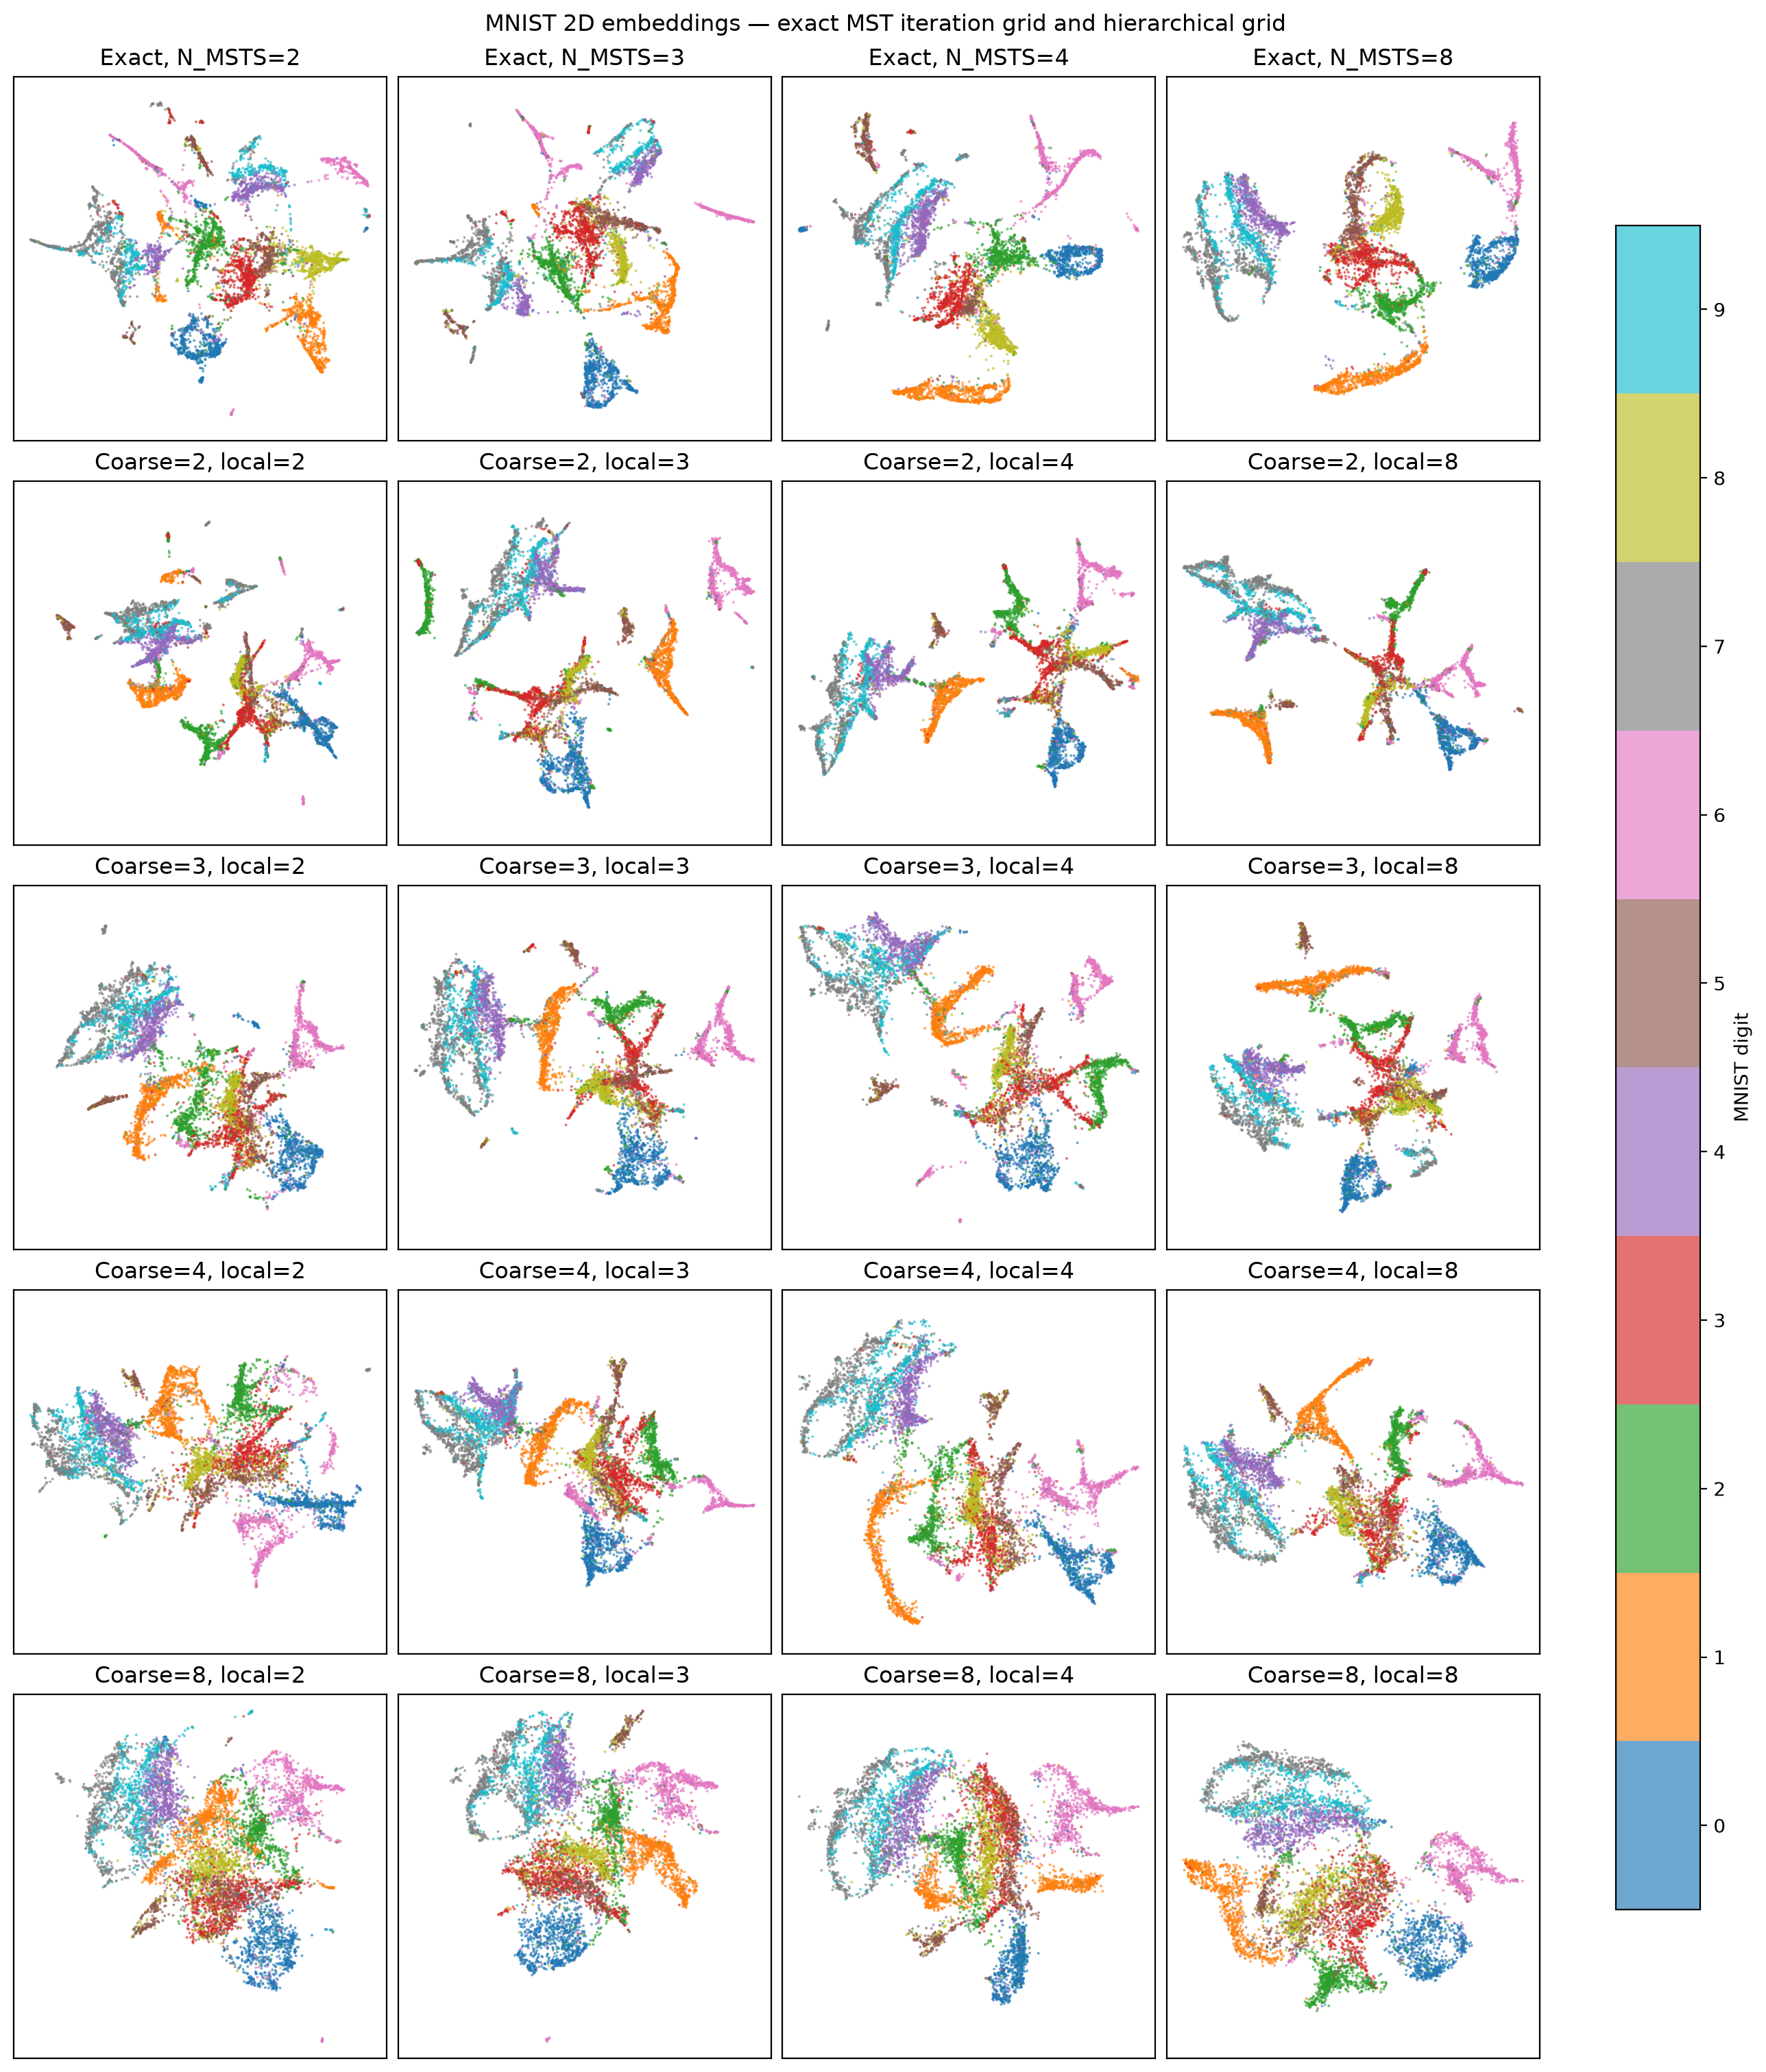

In [6]:
from hierarchical_quality_utils import plot_mnist_embedding_grid

grid_figure = plot_mnist_embedding_grid(
    embeddings,
    digit_labels,
    exact_embeddings,
    coarse_mst_values=N_COARSE_MSTS_VALUES,
    local_mst_values=N_LOCAL_MSTS_VALUES,
)
grid_figure
